# Building a CNN for Classification


In this lab, you will work through the complete pipeline for developing a Convolutional Neural Network (CNN) for a nature image classification task. Along the way, you will implement the model architecture, adopt an iterative development strategy by starting with a smaller prototype, and learn how to identify and interpret common training challenges.

You will:

* **Prepare a Multi-Class Dataset**
  Load, preprocess, and transform a curated collection of nature images for classification across multiple categories.

* **Design and Implement a CNN**
  Build a CNN architecture from scratch using convolutional, pooling, and fully connected layers to extract and learn meaningful image features.

* **Train an Initial Prototype**
  Begin with a smaller 9-class subset to develop a functional prototype, validate the workflow, and establish a baseline level of performance.

* **Expand the Model and Evaluate Performance**
  Train the network on the full 15-class dataset and investigate model behavior to identify challenges such as overfitting and class-level performance differences.


## Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import helper_utils

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Preparing the Nature Dataset

For this lab, you will work with a subset of images from the widely used [CIFAR-100 dataset](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR100.html). This dataset is commonly used in computer vision research and contains thousands of small **32×32 RGB images**, making it well-suited for training convolutional neural networks. Its diversity also makes it a strong foundation for an expanded nature classification application.

Although CIFAR-100 includes 100 classes, only a selected subset will be used here. In order to align with the requirements of the application, the focus will be on **15 classes** representing three categories within a nature theme: flowers, mammals, and insects. The selected classes are:

* **Flowers**: orchid, poppy, rose, sunflower, tulip
* **Mammals**: fox, porcupine, possum, raccoon, skunk
* **Insects**: bee, beetle, butterfly, caterpillar, cockroach

### Image Transformations

Before loading the dataset, you will define the preprocessing and augmentation pipelines. Since all images are already standardized at **32×32 pixels**, no resizing step is required. The training pipeline will include data augmentation to improve generalization, while both training and evaluation pipelines will convert images into tensors and apply normalization using the standard CIFAR-100 statistics.

* Specify the mean and standard deviation values used for normalizing the CIFAR-100 dataset.


In [3]:
cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

* Define two separate pipelines using `transforms.Compose`.
    * One for the training set that includes data augmentation and another for the validation set.

In [4]:
# Training set transformation pipeline
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

# Validation set transformation pipeline
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

### Preparing the Data Pipeline

With the transformations defined, the next step is to load the dataset. To quickly demonstrate a functional prototype, it is advisable to begin with a smaller, more tractable subset of the data. This approach enables validation of the full pipeline while reducing training time and computational cost, allowing for faster iteration and debugging.

Instead of immediately using all 15 classes, the initial model will be trained on a balanced subset of 9 classes, consisting of three categories with three classes each. This staged approach reflects a standard practice in applied machine learning, where simpler setups are used to establish a reliable baseline before scaling up.

For this prototype stage, the selected classes are:

* **Flowers**: orchid, poppy, sunflower
* **Mammals**: fox, raccoon, skunk
* **Insects**: butterfly, caterpillar, cockroach


* Create a Python list containing the names of the 9 classes you'll use for the initial prototype.

In [5]:
subset_target_classes = [
    # Flowers
    'orchid', 'poppy', 'sunflower',
    # Mammals
    'fox', 'raccoon', 'skunk',
    # Insects
    'butterfly', 'caterpillar', 'cockroach'
]

* Use the `load_cifar100_subset` helper function, passing in your `subset_target_classes` list and both transformation pipelines.
* This function handles the entire loading process: it downloads the full CIFAR-100 dataset, applies your specified transformations, and then filters the result to include only the **9 classes** you selected.
* It returns the final training and validation dataset objects, ready for the next step.

In [6]:
# Call the helper function to prepare the datasets
train_dataset_proto, val_dataset_proto = helper_utils.load_cifar100_subset(subset_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Dataset loaded successfully.

Filtering for 9 classes...
Filtering complete. Returning training and validation datasets.


* With your `Dataset` objects ready, the final step in the data pipeline is to create `DataLoaders`.

In [7]:
# Set the number of samples to be processed in each batch
batch_size = 64

# Create a data loader for the training set, with shuffling enabled
train_loader_proto = DataLoader(train_dataset_proto, batch_size=batch_size, shuffle=True)

# Create a data loader for the validation set, without shuffling
val_loader_proto = DataLoader(val_dataset_proto, batch_size=batch_size, shuffle=False)

### Visualizing the Training Images

With your data pipeline complete, it's always a good idea to look at a few examples from your training set. This helps confirm that your data has been loaded and processed correctly. The following helper function will display a random sample of your training images.

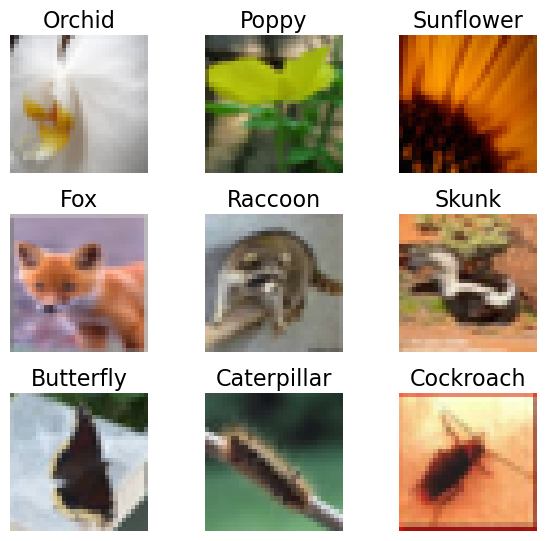

In [8]:
# Visualize a 3x3 grid of random training images
helper_utils.visualise_images(train_dataset_proto, grid=(3, 3))

## Building the CNN Architecture

With the dataset prepared, the next step is to construct the core model for the nature classification task. Standard linear layers alone are insufficient for image data, as they treat each pixel independently and do not capture spatial structure or local relationships within the image.

To address this, you will implement a **Convolutional Neural Network (CNN)**, an architecture designed specifically for visual data. CNNs learn hierarchical representations of images by applying trainable filters that detect edges, textures, and higher-level patterns. The model will be defined using PyTorch’s `nn.Module`, combining multiple layer types to build an effective image classifier.

The main components of the network are as follows:

**Convolutional Layer ([`nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html))**
This is the fundamental building block of a CNN. It applies learnable filters across the input image to extract spatial features, producing feature maps that indicate where specific patterns appear.

* `in_channels`: Number of input channels (3 for RGB images in the first layer)
* `out_channels`: Number of filters learned by the layer, determining the depth of the output feature maps
* `kernel_size`: Size of the sliding filter (e.g., 3×3) used to scan local regions of the image
* `padding`: Adds a border around the input to preserve spatial dimensions and ensure edge information is captured

**ReLU Activation Function ([`nn.ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html))**
Introduces non-linearity by setting all negative values in the feature maps to zero. This enables the network to learn more complex and expressive patterns beyond linear relationships.

**Max Pooling Layer ([`nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html))**
Performs downsampling by sliding a window over the feature maps and retaining only the maximum value within each region. This reduces spatial dimensions and computational cost while preserving the most salient features.

* `kernel_size`: Size of the pooling window (e.g., 2×2)
* `stride`: Step size of the window movement; a stride of 2 typically halves the spatial dimensions

**Flatten Layer ([`nn.Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html))**
Reshapes multi-dimensional feature maps into a one-dimensional vector, enabling compatibility with fully connected layers.

**Linear Layer ([`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html))**
A fully connected layer that integrates learned features to produce class predictions. It forms the final stages of the classification pipeline.

**Dropout Layer ([`nn.Dropout`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html))**
A regularization technique that randomly deactivates a fraction of neurons during training. This reduces overfitting by encouraging the network to learn more robust and distributed feature representations.


In [9]:
class SimpleCNN(nn.Module):
    """
    A simple Convolutional Neural Network model.

    The architecture consists of three convolutional blocks followed by two
    fully connected layers for classification.
    """
    def __init__(self, num_classes):
        """
        Initializes the layers of the neural network.

        Args:
            num_classes: The number of output classes for the final layer.
        """
        # Call the constructor of the parent class (nn.Module)
        super(SimpleCNN, self).__init__()
        
        # Define the first convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define the second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define the third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Define the layer to flatten the feature maps
        self.flatten = nn.Flatten()

        # Define the fully connected (dense) layers
        # Input image is 32x32, after 3 pooling layers: 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)


    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x: The input tensor of shape (batch_size, channels, height, width).

        Returns:
            The output tensor containing the logits for each class.
        """
        # Pass input through the first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Pass feature maps through the second convolutional block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Pass feature maps through the third convolutional block
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Flatten the output for the fully connected layers
        x = self.flatten(x)

        # Pass the flattened features through the fully connected layers
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)

        # Return the final output logits
        return x

With the `SimpleCNN` architecture defined, the next step is to create an instance of the model for your prototype.

* First, dynamically determine the number of output classes by checking the length of the class list in your `train_dataset_proto`.
* Create an instance of your `SimpleCNN`, passing `num_classes` to its constructor.

In [10]:
# Get the number of classes
num_classes = len(train_dataset_proto.classes)

# Instantiate the model
prototype_model = SimpleCNN(num_classes)

Before you start training, it's very helpful to visualize how the shape of your data changes as it flows through the CNN. This will confirm that your architecture is set up correctly and show you how the spatial dimensions shrink while the number of channels grows with each convolutional block.

* Define the `print_data_flow` helper function. 
    * This function will pass a sample 32x32 color image through your model, layer by layer, printing the tensor's shape at each key step to trace its journey from input to final prediction.

In [11]:
def print_data_flow(model):
    """
    Prints the shape of a tensor as it flows through each layer of the model.

    Args:
        model: An instance of the PyTorch model to inspect.
    """
    # Create a sample input tensor (batch_size, channels, height, width)
    x = torch.randn(1, 3, 32, 32)

    # Track the tensor shape at each stage
    print(f"Input shape: \t\t{x.shape}")

    # First conv block
    x = model.conv1(x)
    print(f"After conv1: \t\t{x.shape}")
    x = model.relu1(x)
    x = model.pool1(x)
    print(f"After pool1: \t\t{x.shape}")

    # Second conv block
    x = model.conv2(x)
    print(f"After conv2: \t\t{x.shape}")
    x = model.relu2(x)
    x = model.pool2(x)
    print(f"After pool2: \t\t{x.shape}")

    # Third conv block
    x = model.conv3(x)
    print(f"After conv3: \t\t{x.shape}")
    x = model.relu3(x)
    x = model.pool3(x)
    print(f"After pool3: \t\t{x.shape}")

    # Flatten using the model's flatten layer
    x = model.flatten(x)
    print(f"After flatten: \t\t{x.shape}")

    # Fully connected layers
    x = model.fc1(x)
    print(f"After fc1: \t\t{x.shape}")
    x = model.relu4(x)
    x = model.dropout(x)
    x = model.fc2(x)
    print(f"Output shape (fc2): \t{x.shape}")

You can now print a summary of your model and trace the data flow to see it in action.

* Call your helper function to print the tensor's shape at each step.

    * The tensor starts as a `(1, 3, 32, 32)` image. As it passes through the `conv` and `pool` blocks, the number of **channels increases** while the **spatial size is halved** at each step.

    * The final `(1, 128, 4, 4)` feature map is **flattened** into a 1D vector to be processed by the linear layers. The model's final **output shape is** `(1, 9)`, providing one score for each of the 9 classes.

In [12]:
# Print the model's architecture
print(prototype_model)

# Call the helper function to visualize the data flow
print("\n--- Tracing Data Flow ---")
print_data_flow(prototype_model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)

--- Tracing Data Flow ---
Input shape: 		torch.Size([1, 3, 32, 32])
After conv1: 		torch.Size([1, 32, 32, 32])
After pool1: 		torch.Size([1, 32, 16, 16])
After conv2: 		torch.Size([1, 64, 16, 16])
After pool2: 		t

## Training the Model

With your model defined and the data pipeline prepared, you're ready to set up the training process. This involves initializing a loss function to measure your model's error and an optimizer to update its weights based on that error.

### Initialize Loss Function and Optimizer

Before starting the training loop, you'll define two key components:

* You'll use <code>[nn.CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)</code>. This is the standard loss function for multi-class classification tasks as it's designed to measure the error when a model has to choose one class from several possibilities.
* You'll use the <code>[Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)</code> optimizer. This is a popular and efficient algorithm that updates the model's weights to minimize the loss.

In [13]:
# Loss function
loss_function = nn.CrossEntropyLoss()

# Optimizer for the prototype model
optimizer_prototype = optim.Adam(prototype_model.parameters(), lr=0.001)

### The Training Loop

* Next, you'll define the `training_loop` function. This function encapsulates the entire process of training and validating your model over multiple epochs.

In [14]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    """
    Trains and validates a PyTorch neural network model.

    Args:
        model: The neural network model to be trained.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        loss_function: The loss function to use for training.
        optimizer: The optimization algorithm.
        num_epochs: The total number of epochs to train for.
        device: The device (e.g., 'cpu' or 'cuda') to run the training on.

    Returns:
        A tuple containing:
        - The trained model.
        - A list of metrics [train_losses, val_losses, val_accuracies].
    """
    # Move the model to the specified device (CPU or GPU)
    model.to(device)
    
    # Initialize lists to store training and validation metrics
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    # Print a message indicating the start of the training process
    print("--- Training Started ---")
    
    # Loop over the specified number of epochs
    for epoch in range(num_epochs):
        # Set the model to training mode
        model.train()
        # Initialize running loss for the current epoch
        running_loss = 0.0
        # Iterate over batches of data in the training loader
        for images, labels in train_loader:
            # Move images and labels to the specified device
            images, labels = images.to(device), labels.to(device)
            
            # Clear the gradients of all optimized variables
            optimizer.zero_grad()
            # Perform a forward pass to get model outputs
            outputs = model(images)
            # Calculate the loss
            loss = loss_function(outputs, labels)
            # Perform a backward pass to compute gradients
            loss.backward()
            # Update the model parameters
            optimizer.step()
            
            # Accumulate the training loss for the batch
            running_loss += loss.item() * images.size(0)
            
        # Calculate the average training loss for the epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        # Append the epoch loss to the list of training losses
        train_losses.append(epoch_loss)
        
        # Set the model to evaluation mode
        model.eval()
        # Initialize running validation loss and correct predictions count
        running_val_loss = 0.0
        correct = 0
        total = 0
        # Disable gradient calculations for validation
        with torch.no_grad():
            # Iterate over batches of data in the validation loader
            for images, labels in val_loader:
                # Move images and labels to the specified device
                images, labels = images.to(device), labels.to(device)
                
                # Perform a forward pass to get model outputs
                outputs = model(images)
                
                # Calculate the validation loss for the batch
                val_loss = loss_function(outputs, labels)
                # Accumulate the validation loss
                running_val_loss += val_loss.item() * images.size(0)
                
                # Get the predicted class labels
                _, predicted = torch.max(outputs, 1)
                # Update the total number of samples
                total += labels.size(0)
                # Update the number of correct predictions
                correct += (predicted == labels).sum().item()
                
        # Calculate the average validation loss for the epoch
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        # Append the epoch validation loss to the list
        val_losses.append(epoch_val_loss)
        
        # Calculate the validation accuracy for the epoch
        epoch_accuracy = 100.0 * correct / total
        # Append the epoch accuracy to the list
        val_accuracies.append(epoch_accuracy)
        
        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")
        
    # Print a message indicating the end of the training process
    print("--- Finished Training ---")
    
    # Consolidate all metrics into a single list
    metrics = [train_losses, val_losses, val_accuracies]
    
    # Return the trained model and the collected metrics
    return model, metrics

With all the necessary components assembled, the training phase can now begin.

* Execute the `training_loop` function using the prototype model (configured for 9 classes), along with the appropriate data loaders, loss function, and optimizer.
* The model will be trained for **15 epochs**, and the function will return both the trained model and the recorded performance metrics.
* Once training has finished, use the `plot_training_metrics` utility function to visualize the training and validation loss, as well as the validation accuracy over time.


--- Training Started ---
Epoch [1/15], Train Loss: 1.6070, Val Loss: 1.2792, Val Accuracy: 53.00%
Epoch [2/15], Train Loss: 1.2066, Val Loss: 1.0361, Val Accuracy: 65.22%
Epoch [3/15], Train Loss: 1.0665, Val Loss: 0.9075, Val Accuracy: 68.56%
Epoch [4/15], Train Loss: 0.9507, Val Loss: 0.8284, Val Accuracy: 72.78%
Epoch [5/15], Train Loss: 0.8578, Val Loss: 0.8223, Val Accuracy: 73.22%
Epoch [6/15], Train Loss: 0.8043, Val Loss: 0.8609, Val Accuracy: 71.56%
Epoch [7/15], Train Loss: 0.7465, Val Loss: 0.7414, Val Accuracy: 75.22%
Epoch [8/15], Train Loss: 0.6907, Val Loss: 0.7087, Val Accuracy: 77.22%
Epoch [9/15], Train Loss: 0.6412, Val Loss: 0.7171, Val Accuracy: 76.67%
Epoch [10/15], Train Loss: 0.6117, Val Loss: 0.6919, Val Accuracy: 77.44%
Epoch [11/15], Train Loss: 0.5775, Val Loss: 0.6879, Val Accuracy: 77.44%
Epoch [12/15], Train Loss: 0.5286, Val Loss: 0.6873, Val Accuracy: 77.00%
Epoch [13/15], Train Loss: 0.5038, Val Loss: 0.6725, Val Accuracy: 79.44%
Epoch [14/15], Train L

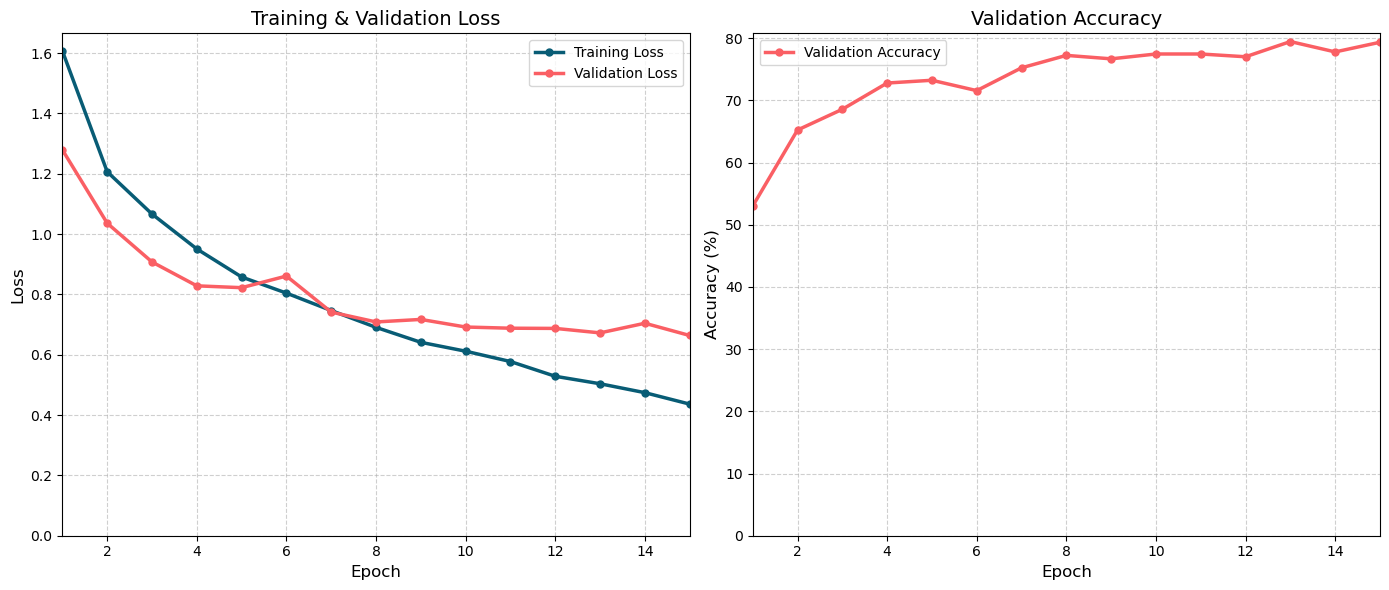

In [15]:
# Start the training process by calling the training loop function
trained_proto_model, training_metrics_proto = training_loop(
    model=prototype_model, 
    train_loader=train_loader_proto, 
    val_loader=val_loader_proto, 
    loss_function=loss_function, 
    optimizer=optimizer_prototype, 
    num_epochs=15, 
    device=device
)

# Visualize the training metrics (loss and accuracy)
print("\n--- Training Plots ---\n")
helper_utils.plot_training_metrics(training_metrics_proto)

The prototype model has been successfully trained, and the outcomes are encouraging. A validation accuracy exceeding **75%** on the 9-class subset indicates strong performance and suggests that the CNN architecture is appropriate for the task.

This validated prototype provides a solid foundation to proceed to the next stage: training a full-scale model on all 15 classes for the butterfly house application. Before moving forward, however, it is useful to conduct a qualitative assessment of the model’s behavior.

### Visualizing Predictions

Although the performance curves provide an overall view of training progress, inspecting individual predictions offers deeper insight into how the model behaves in practice. A helper function can now be used to visualize predictions on random samples from the validation set. This allows direct examination of cases where the model performs well, as well as instances where it makes errors.


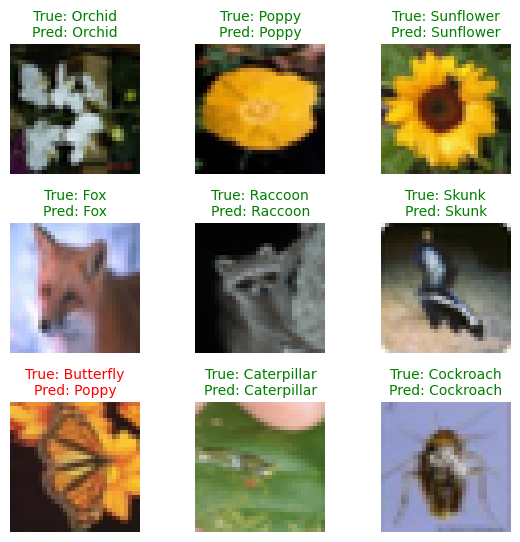

In [16]:
# Visualize model predictions on a sample of validation images
helper_utils.visualise_predictions(
    model=trained_proto_model, 
    data_loader=val_loader_proto, 
    device=device, 
    grid=(3, 3)
)

## Scaling Up: Training the Full Model

The prototype has performed successfully, and the next step is to proceed with training the final model. This stage follows the same workflow as before, but now uses the complete and more demanding dataset containing **15 classes**.

* Begin by defining a new list that includes all 15 target categories.
* Reuse the `load_cifar100_subset` helper function to construct updated training and validation datasets based on this expanded class list.


In [17]:
# Define the full class list.
all_target_classes = [
    # Flowers
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    # Mammals
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    # Insects
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

# Load the full datasets.
train_dataset, val_dataset = helper_utils.load_cifar100_subset(all_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Dataset loaded successfully.

Filtering for 15 classes...
Filtering complete. Returning training and validation datasets.


<br>

* Wrap your new 15-class datasets in `DataLoader` instances, using the same `batch_size=64`.

In [18]:
# Create a data loader for the training set, with shuffling enabled
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create a data loader for the validation set, without shuffling
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

* Display a sample of images from your new 15-class training set to confirm it has been loaded correctly.

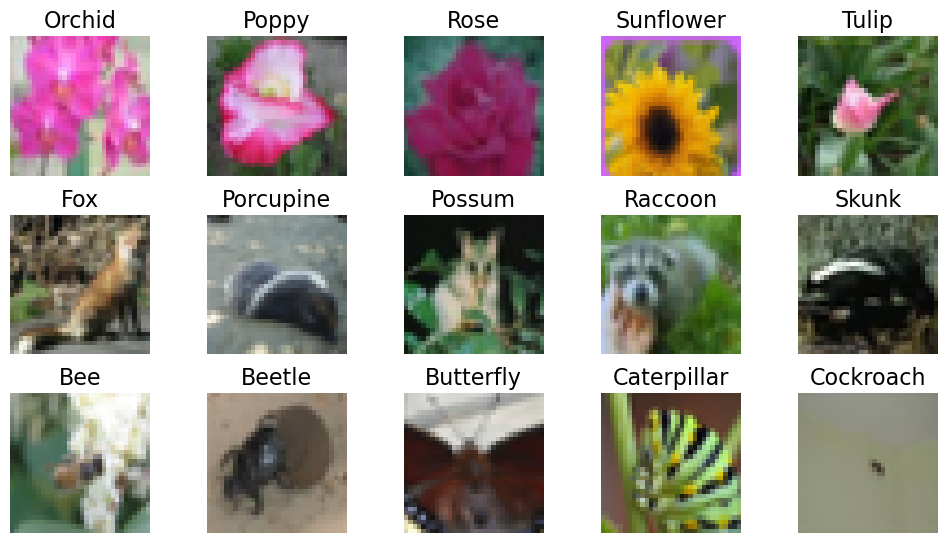

In [19]:
# Visualize a 3x5 grid of random training images
helper_utils.visualise_images(train_dataset, grid=(3, 5))

<br>

* Create a new instance of your `SimpleCNN` model, this time configured for all **15 classes**.

In [20]:
# Get the number of classes
num_classes = len(train_dataset.classes)

# Instantiate the full model
model = SimpleCNN(num_classes)

# Print the model's architecture (notice, it now has 15 output classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=15, bias=True)
)


<br>

* Create a new `Adam` optimizer for your full 15-class model.

In [21]:
# Optimizer for the full model
optimizer = optim.Adam(model.parameters(), lr=0.001)

* Call the `training_loop` to train your 15-class model for `25 epochs`. The `plot_training_metrics` function will then immediately visualize the loss and accuracy curves from this final training run.

In [ ]:
# Start the training process for the full model on all 15 classes
trained_model, training_metrics = training_loop(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    num_epochs=25, 
    device=device
)

# Visualize the training metrics for the full model
print("\n--- Training Plots ---\n")
helper_utils.plot_training_metrics(training_metrics)

--- Training Started ---
Epoch [1/25], Train Loss: 2.1877, Val Loss: 1.8390, Val Accuracy: 38.60%


<br>

After training the full model, you can analyze the results. But wait, something isn't right here. Your prototype model trained successfully, showing steady improvement. However, the performance on the full 15-class dataset seems to have hit a wall. What happened?

A close look at the plots reveals the problem. While the **Training Loss** consistently decreases, the **Validation Loss** drops for a while and then begins to rise and fluctuate. At the same time, the **Validation Accuracy** gets stuck, plateauing without making further significant progress. This is a classic case of **overfitting**.

Overfitting occurs when a model learns the training data *too well*, including its noise and specific quirks, instead of the general, underlying patterns that would help it perform on new, unseen data. The widening gap between your training and validation loss is a clear sign your model is memorizing the training set instead of learning to **generalize**.

You might wonder why this happened now and not with the 9-class prototype. The reason is the significant increase in **task complexity**. Distinguishing between 15 classes is much harder than 9, requiring the model to learn more subtle features. Faced with this harder challenge, your powerful CNN model found an easier path to lowering the training loss: it started to memorize the training data instead of learning to generalize.

This overfitting problem presents a realistic challenge, similar to what you'd encounter in a real-world project. In this module's graded assignment, you'll tackle this issue by making several updates to your entire pipeline to see if you can improve the model's ability to generalize.

In [ ]:
helper_utils.visualise_predictions(
    model=trained_model, 
    data_loader=val_loader, 
    device=device, 
    grid=(3, 5)
)

## Conclusion

Congratulations on completing the lab! You have successfully navigated the entire machine learning pipeline, from data preparation to building, training, and analyzing your very own Convolutional Neural Network.

You've put theory into practice by building a CNN architecture capable of learning complex visual patterns. More importantly, you've experienced a realistic, iterative development workflow by first creating a successful prototype and then scaling up to a more complex model. This process led you to encounter and diagnose overfitting, a fundamental challenge that every machine learning practitioner must learn to solve.

The skills you've developed here have prepared you for the next step. You've identified the problem, and in the graded assignment, you'll get to solve it. Well done!